# 5-1 딥러닝에 맞는 이미지 취급법

본 노트북은 본문 5-1 절의 코드 예제([코드 5-1], [코드 5-2])를 절 흐름 그대로 모은 것이다. 합성곱 연산으로 이미지에서 특징을 찾는 원리를 직접 구현해 본다.

다루는 내용
- `[코드 5-1]` 두 텐서 사이의 합성곱 연산
- `[코드 5-2]` 합성곱 필터를 이미지 전체에 적용해 특징 지도 생성
- (참고) 세로 경계 필터 특징 지도 시각화([그림 5-7]), 풀링 비교([그림 5-8])

> MNIST 자동 다운로드 데이터는 공개 저장소 규약(§13.9)에 따라 `root='../../download'` 로 받는다. 본문 경로는 `'../data'` 이며, 이 차이는 `_book` 에 기록한다.

## 참고 - 라이브러리 설치 (이미 설치된 경우 건너뛰어도 좋다)

torchvision 은 기본 의존성으로 README 에서 안내한다. 별도 설치가 필요하면 아래를 사용한다.

In [1]:
# 참고 - 라이브러리 설치 (이미 설치된 경우 건너뛰어도 좋다)
# !pip install -q torchvision

## 라이브러리 import 와 시드 고정

In [2]:
# 참고 - 환경 설정 (code_reference 모듈 임포트 경로와 시각화 설정)
import sys
sys.path.append('../../')

from code_reference import common
# viz.configure()에서 save_grayscale=True로 지정하면 노트북에 표시되는 시각화 이미지를 파일로 저장함
from code_reference import visualize as viz

common.set_korean_plot_env()
viz.configure(save_grayscale=False)

In [3]:
# 참고 - 라이브러리 import 와 시드 고정
import random

import numpy as np
import torch
from torchvision import datasets, transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## [코드 5-1] 두 텐서 사이의 합성곱 연산

합성곱 연산은 위치가 같은 원소끼리 곱한 뒤 모두 더하는 연산이다. 두 텐서의 형태가 같아야 하며, 결과는 스칼라값이다.

In [ ]:
# 코드 5-1 - 두 텐서 사이의 합성곱 연산

# 두 텐서에서 위치가 같은 원소끼리 곱한 후 모두 더하는 합성곱 연산 함수
def conv_operation(tensor_1, tensor_2):
    if tensor_1.shape != tensor_2.shape:
        raise ValueError('형태가 같은 텐서끼리만 합성곱 계산이 가능합니다.')
    return torch.sum(tensor_1 * tensor_2).item()    # 합성곱 연산 결과는 스칼라


tensor_1 = torch.tensor([[1, 2], [3, 4]])
tensor_2 = torch.tensor([[5, 6], [7, 8]])
print(conv_operation(tensor_1, tensor_2))           

70


## [코드 5-2] 합성곱 필터를 이미지 전체에 적용

`make_feature_map()` 함수는 이미지(`img_tensor`) 전체에 합성곱 필터(`conv_filter`)를 적용해, 이미지 속 3x3 부분 이미지와 필터의 합성곱 연산 결과를 위치에 맞게 재구성한 특징 지도 텐서를 반환한다. 3x3 필터를 28x28 이미지에 적용하면 가장자리를 제외한 26x26 특징 지도가 만들어진다.

In [ ]:
# 코드 5-2 - 합성곱 필터를 이미지 전체에 적용

# data_root: MNIST 데이터셋을 다운로드할 경로
data_root = '../../download'

# 합성곱 필터를 이미지 전체에 적용해 특징 지도를 만드는 함수
def make_feature_map(img_tensor, conv_filter):
    # img_tensor(이미지 텐서): 1 채널 이미지 (1, H, W) 형태
    _, H, W = img_tensor.shape
    # conv_filter(필터): (F_H, F_W) 형태의 텐서 (F_H, F_W는 각각 필터 세로, 가로 크기)
    F_H, F_W = conv_filter.shape
    # 빈 특징 지도를 합성곱 연산 결과로 채움
    feature_map = torch.zeros((H - F_H + 1, W - F_W + 1))
    # 합성곱 필터를 한 픽셀씩 이동하면서 이미지 전체에 적용
    for y in range(H - F_H + 1):
        for x in range(W - F_W + 1):
            # 이미지의 3x3 부분 영역을 (3, 3) 형태의 텐서로 슬라이싱
            partial_img = img_tensor[0, y:y + F_H, x:x + F_W]
            # 부분 영역 텐서와 필터 텐서의 합성곱 연산
            conv_value = conv_operation(partial_img, conv_filter)
            feature_map[y, x] = conv_value
    return feature_map

# 특징 지도 확인 용도이므로 텐서 변환(ToTensor)만 적용
test_set = datasets.MNIST(
    root=data_root, train=False,
    download=True, transform=transforms.ToTensor(),
)

# 왼쪽이 밝고, 오른쪽이 어두운 세로 방향 경계선을 탐지하는 필터
vertical_filter = torch.tensor(
    [[1., 0., -1.], 
     [1., 0., -1.], 
     [1., 0., -1.]]
)

# 이미지 샘플의 세로 방향 경계선 특징 지도 생성
feature_map = make_feature_map(test_set[0][0], vertical_filter)

print(f'특징 지도의 형태: {tuple(feature_map.shape)}')   # (26, 26)

특징 지도의 형태: (26, 26)


## 참고 - [그림 5-7] 대응: 각 숫자별 세로 경계 필터 특징 지도

0~9 각 숫자의 첫 샘플에 세로 경계 필터를 적용해 특징 지도를 만든다. 주로 세로 방향 획의 왼쪽이 진하게 나타난다.

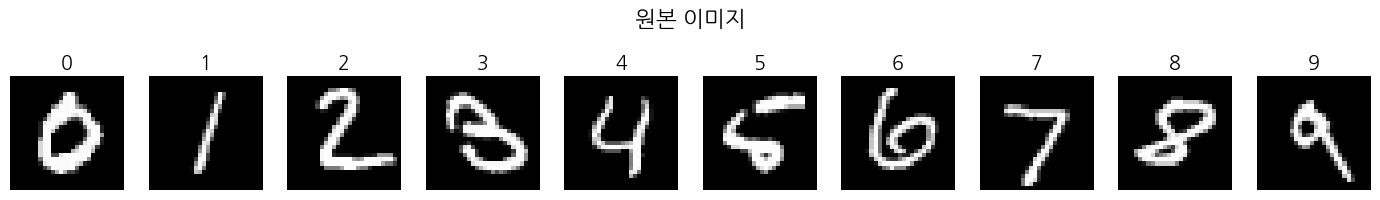

In [ ]:
# [그림 5-7] 원본 이미지

# 0~9 각 숫자의 첫 번째 샘플 인덱스를 찾는다
first_indices = {}
for idx in range(len(test_set)):
    _, label = test_set[idx]
    if label not in first_indices:
        first_indices[label] = idx
    if len(first_indices) == 10:
        break

sample_indices = [first_indices[d] for d in range(10)]
samples = [test_set[i][0] for i in sample_indices]
labels = [test_set[i][1] for i in sample_indices]

# 원본 이미지 출력
viz.plot_images(
    samples, [f'{y}' for y in labels], images_per_row=10, title='원본 이미지'
)

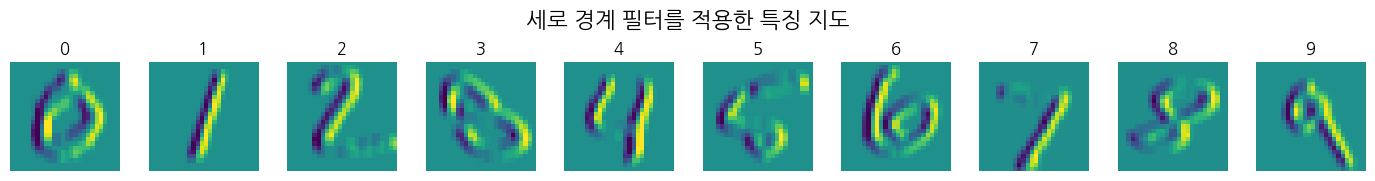

In [ ]:
# [그림 5-7] - 세로 경계 필터를 적용한 특징 지도

feature_maps = torch.stack(
    [make_feature_map(s, vertical_filter) for s in samples]
)
# (10, 26, 26) 형태를 (C, H, W) 로 간주해 plot_feature_map 사용
viz.plot_feature_map(
    feature_maps,
    title='세로 경계 필터를 적용한 특징 지도',
    images_per_row=10,
    channel_names=[f'{y}' for y in labels],
)

## 참고 - [그림 5-8] 대응: 풀링으로 특징 지도 요약

26x26 특징 지도를 2x2 영역으로 최대 풀링/평균 풀링하면 13x13 크기로 줄어든다. 시각적 비교를 위해 같은 크기로 보간해 나란히 표시한다.

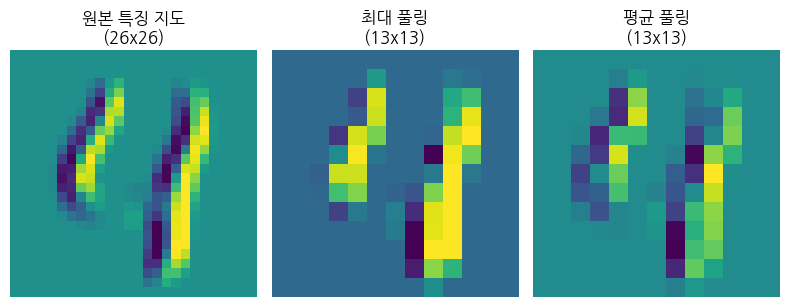

최대 풀링 후 크기: (13, 13)
평균 풀링 후 크기: (13, 13)


In [ ]:
# [그림 5-8] - 26x26 특징 지도의 최대/평균 풀링 비교
import torch.nn.functional as F

# 숫자 0 샘플의 특징 지도를 (1, 1, 26, 26) 형태로 풀링 API 입력에 맞춤
sample_map = feature_maps[4].unsqueeze(0).unsqueeze(0)
max_pooled = F.max_pool2d(sample_map, kernel_size=2)
avg_pooled = F.avg_pool2d(sample_map, kernel_size=2)

summary_maps = torch.stack([
    sample_map.squeeze(),                                   # (26, 26)
    F.interpolate(max_pooled, size=(26, 26)).squeeze(),
    F.interpolate(avg_pooled, size=(26, 26)).squeeze(),
])
viz.plot_feature_map(
    summary_maps,    
    images_per_row=3,
    channel_names=['원본 특징 지도\n(26x26)', '최대 풀링\n(13x13)', '평균 풀링\n(13x13)'],
    figsize=(8, 5),
)
print(f'최대 풀링 후 크기: {tuple(max_pooled.squeeze().shape)}')   # (13, 13)
print(f'평균 풀링 후 크기: {tuple(avg_pooled.squeeze().shape)}')   # (13, 13)

## 정리

- 합성곱 연산은 위치가 같은 원소끼리 곱해 더하는 연산으로, 필터로 2차원 패턴을 탐지한다.
- 필터를 이미지 전체에 적용해 만든 특징 지도는 특정 특징이 어디에 얼마나 강하게 있는지를 나타낸다.
- 풀링은 특징 지도를 일정 영역 단위로 요약해 크기를 줄이고 이동 불변성을 강화한다.